### Maximum likelihood difference scaling
Edit the numbers marked `👈` and re-run.

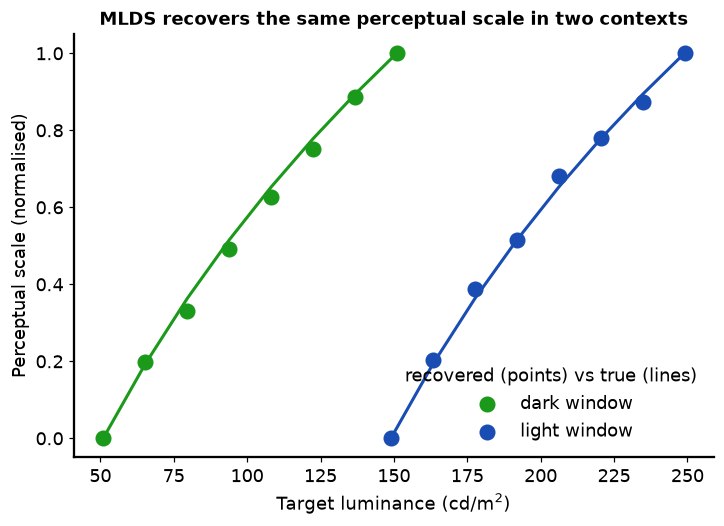

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.optimize import minimize

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
rng = np.random.default_rng()

# --- Two viewing contexts: the stimulus is seen through a dark or a light
#     transparent "window", which shifts the luminance reaching the eye. ---
nstim  = 8
base   = np.linspace(100, 200, nstim)   # target luminance with no window (cd/m^2)
window = 49                             # 👈 how much the window shifts luminance
darkLum  = base - window                # dark window lowers the luminance
lightLum = base + window                # light window raises it

# The observer's perception is a compressive (log) function of luminance, but
# lightness constancy means they perceive the SAME lightness in both windows.
percept = np.log(base)                  # 👈 the (compressive) perceptual scale
percept = (percept - percept.min()) / (percept.max() - percept.min())

noiseSD = 0.10   # 👈 perceptual noise
nreps   = 12     # 👈 repeats of each triad

# --- MLDS: simulate triad judgements for a context and recover its scale ---
def recover_scale(perceived):
    X, y = [], []
    for (i, j, k) in combinations(range(nstim), 3):        # each triad i<j<k
        for _ in range(nreps):
            p = perceived[[i, j, k]] + rng.normal(0, noiseSD, 3)
            resp = abs(p[1] - p[2]) > abs(p[0] - p[1])      # 2nd pair more different?
            row = np.zeros(nstim); row[i] += 1; row[j] += -2; row[k] += 1
            X.append(row); y.append(int(resp))
    X, y = np.array(X), np.array(y)
    Xfit = X[:, 1:]                                         # fix stimulus 1 at 0
    def nll(b):
        pr = np.clip(1 / (1 + np.exp(-(Xfit @ b))), 1e-9, 1 - 1e-9)
        return -np.sum(y * np.log(pr) + (1 - y) * np.log(1 - pr))
    b = minimize(nll, np.zeros(nstim - 1), method="BFGS").x
    rec = np.concatenate([[0.0], b])
    return (rec - rec.min()) / (rec.max() - rec.min())

recD = recover_scale(percept)   # dark-window context
recL = recover_scale(percept)   # light-window context (same perception -> constancy)

green, blue = (0.1, 0.6, 0.1), (0.1, 0.3, 0.7)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(darkLum,  percept, color=green, lw=2)
ax.plot(lightLum, percept, color=blue,  lw=2)
ax.scatter(darkLum,  recD, 90, color=green, zorder=3, label="dark window")
ax.scatter(lightLum, recL, 90, color=blue,  zorder=3, label="light window")
ax.set(xlabel="Target luminance (cd/m$^2$)", ylabel="Perceptual scale (normalised)",
       title="MLDS recovers the same perceptual scale in two contexts")
ax.legend(loc="lower right", title="recovered (points) vs true (lines)")
plt.show()
